# Part 2 — Scene-Cut-Aware OC-SORT + OSNet Recovery

This notebook consumes the exact YOLO cache created in Part 1. At a hard cut it discards OC-SORT/Kalman motion state, preserves long-term OSNet appearance memory, and recovers an old identity only when conservative one-to-one matching passes the threshold.

There is **no training or fine-tuning**.

## Improvement invariant

```text
hard cut
├── discard: tracklets, Kalman state, local IDs
└── preserve: global IDs and bounded OSNet embedding galleries
```

The baseline and improved runs share the same `.npz` detection cache.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "configs" / "default.yaml").exists():
    raise RuntimeError("Start this notebook from the project root or notebooks directory.")

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from IPython.display import Image, Video, display
import pandas as pd

from scenecut_tracking.config import load_config
from scenecut_tracking.demo_data import create_demo_video
from scenecut_tracking.detection_cache import DetectionCache, build_detection_cache
from scenecut_tracking.detector import YoloPersonDetector
from scenecut_tracking.evaluation import cross_cut_recovery_summary, evaluate_mot
from scenecut_tracking.runner import run_video
from scenecut_tracking.runtime import configure_runtime, write_json
from scenecut_tracking.visualization import plot_metric_comparison

configure_runtime(PROJECT_ROOT)
CONFIG = load_config(PROJECT_ROOT / "configs" / "default.yaml")

## Load the Part 1 inputs

In [2]:
USE_BUNDLED_DEMO = True
VIDEO_PATH = PROJECT_ROOT / "data" / "videos" / "demo_people.mp4"
GROUND_TRUTH_PATH = PROJECT_ROOT / "data" / "annotations" / "demo_people_gt.txt"
DETECTION_CACHE_PATH = PROJECT_ROOT / "outputs" / "detections" / "demo_people.npz"
BASELINE_OUTPUT = PROJECT_ROOT / "outputs" / "baseline" / "demo"
IMPROVED_OUTPUT = PROJECT_ROOT / "outputs" / "improved" / "demo"
CUT_FRAMES = [24] if USE_BUNDLED_DEMO else []

if not VIDEO_PATH.exists() or not DETECTION_CACHE_PATH.exists():
    detector = YoloPersonDetector(CONFIG["detector"], PROJECT_ROOT)
    if USE_BUNDLED_DEMO:
        create_demo_video(VIDEO_PATH, GROUND_TRUTH_PATH, detector)
    cache = build_detection_cache(VIDEO_PATH, detector, CONFIG["detector"])
    cache.save(DETECTION_CACHE_PATH)

shared_cache = DetectionCache.load(DETECTION_CACHE_PATH)
shared_cache.validate_video(VIDEO_PATH)
print(f"Using the frozen Part 1 cache with {len(shared_cache.rows):,} detections")

Using the frozen Part 1 cache with 96 detections


## Run cut-aware tracking and selective ReID

In [3]:
improved_summary = run_video(
    mode="improved",
    video_path=VIDEO_PATH,
    detection_cache_path=DETECTION_CACHE_PATH,
    output_dir=IMPROVED_OUTPUT,
    config=CONFIG,
    project_root=PROJECT_ROOT,
)
display(pd.DataFrame([improved_summary]))

SUCCESS  | OcSort: det_thresh=0.25, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, delta_t=3, inertia=0.2, use_byte=False, Q_xy_scaling=0.01, Q_s_scaling=0.0001


D:\Bunker\BaseCamp\SceneCut Aware tracking\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO     | BoxMOT v16.0.10 🚀 Python-3.13.1 torch-2.14.0+cpuCPU


INFO     | D:\Bunker\BaseCamp\SceneCut Aware tracking\weights\osnet_x0_25_msmt17.pt


INFO     | [PID 12800] Found existing ReID weights at D:\Bunker\BaseCamp\SceneCut Aware tracking\weights\osnet_x0_25_msmt17.pt; skipping download.


SUCCESS  | Loaded pretrained weights from D:\Bunker\BaseCamp\SceneCut Aware tracking\weights\osnet_x0_25_msmt17.pt


SUCCESS  | OcSort: det_thresh=0.25, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, delta_t=3, inertia=0.2, use_byte=False, Q_xy_scaling=0.01, Q_s_scaling=0.0001


,mode,frames,source_fps,processing_fps,elapsed_seconds,track_rows,unique_global_ids,detected_scene_cuts,cut_frames,accepted_recoveries,average_recovery_similarity,annotated_video,tracks_mot
0,improved,48,12.0,18.610461,2.579195,96,2,1,[24],2,0.986023,D:\Bunker\BaseCamp\SceneCut Aware tracking\out...,D:\Bunker\BaseCamp\SceneCut Aware tracking\out...


## Evaluate the same paper metrics

In [4]:
if GROUND_TRUTH_PATH.exists():
    improved_metrics = evaluate_mot(
        GROUND_TRUTH_PATH,
        IMPROVED_OUTPUT / "tracks_mot.txt",
        iou_threshold=CONFIG["evaluation"]["match_iou_threshold"],
    )
    improved_metrics.update(
        cross_cut_recovery_summary(
            GROUND_TRUTH_PATH,
            IMPROVED_OUTPUT / "tracks_mot.txt",
            CUT_FRAMES,
            iou_threshold=CONFIG["evaluation"]["match_iou_threshold"],
        )
    )
    write_json(improved_metrics, IMPROVED_OUTPUT / "paper_metrics.json")
    display(pd.DataFrame([improved_metrics]))
else:
    improved_metrics = None
    print("Ground truth not supplied: paper and verified recovery metrics were not computed.")

Error importing BURST due to missing underlying dependency: No module named 'pycocotools'


,HOTA,DetA,AssA,IDF1,MOTA,FP,FN,IDs,Frag,GT_detections,Predicted_detections,cross_cut_identities_evaluated,cross_cut_identities_recovered,cross_cut_recovery_rate
0,97.833522,97.795965,97.871239,100.0,100.0,0,0,0,0,96,96,2,2,100.0


## Baseline versus improved

In [5]:
baseline_metrics_path = BASELINE_OUTPUT / "paper_metrics.json"
improved_metrics_path = IMPROVED_OUTPUT / "paper_metrics.json"
if baseline_metrics_path.exists() and improved_metrics_path.exists():
    baseline_metrics = json.loads(baseline_metrics_path.read_text(encoding="utf-8"))
    metric_order = ["HOTA", "AssA", "IDF1", "MOTA", "FP", "FN", "IDs", "Frag"]
    comparison = pd.DataFrame({
        "Metric": metric_order,
        "Baseline": [baseline_metrics[name] for name in metric_order],
        "Improved": [improved_metrics[name] for name in metric_order],
    })
    comparison["Difference"] = comparison["Improved"] - comparison["Baseline"]
    display(comparison)
    plot_metric_comparison(baseline_metrics_path, improved_metrics_path, IMPROVED_OUTPUT)
else:
    print("Run Part 1 with ground truth before producing the comparison table.")

,Metric,Baseline,Improved,Difference
0,HOTA,61.016206,97.833522,36.817316
1,AssA,39.313447,97.871239,58.557792
2,IDF1,50.793651,100.000000,49.206349
3,MOTA,94.791667,100.000000,5.208333
4,FP,0.000000,0.000000,0.000000
5,FN,3.000000,0.000000,-3.000000
6,IDs,2.000000,0.000000,-2.000000
7,Frag,1.000000,0.000000,-1.000000


## Inspect plots, events, and video

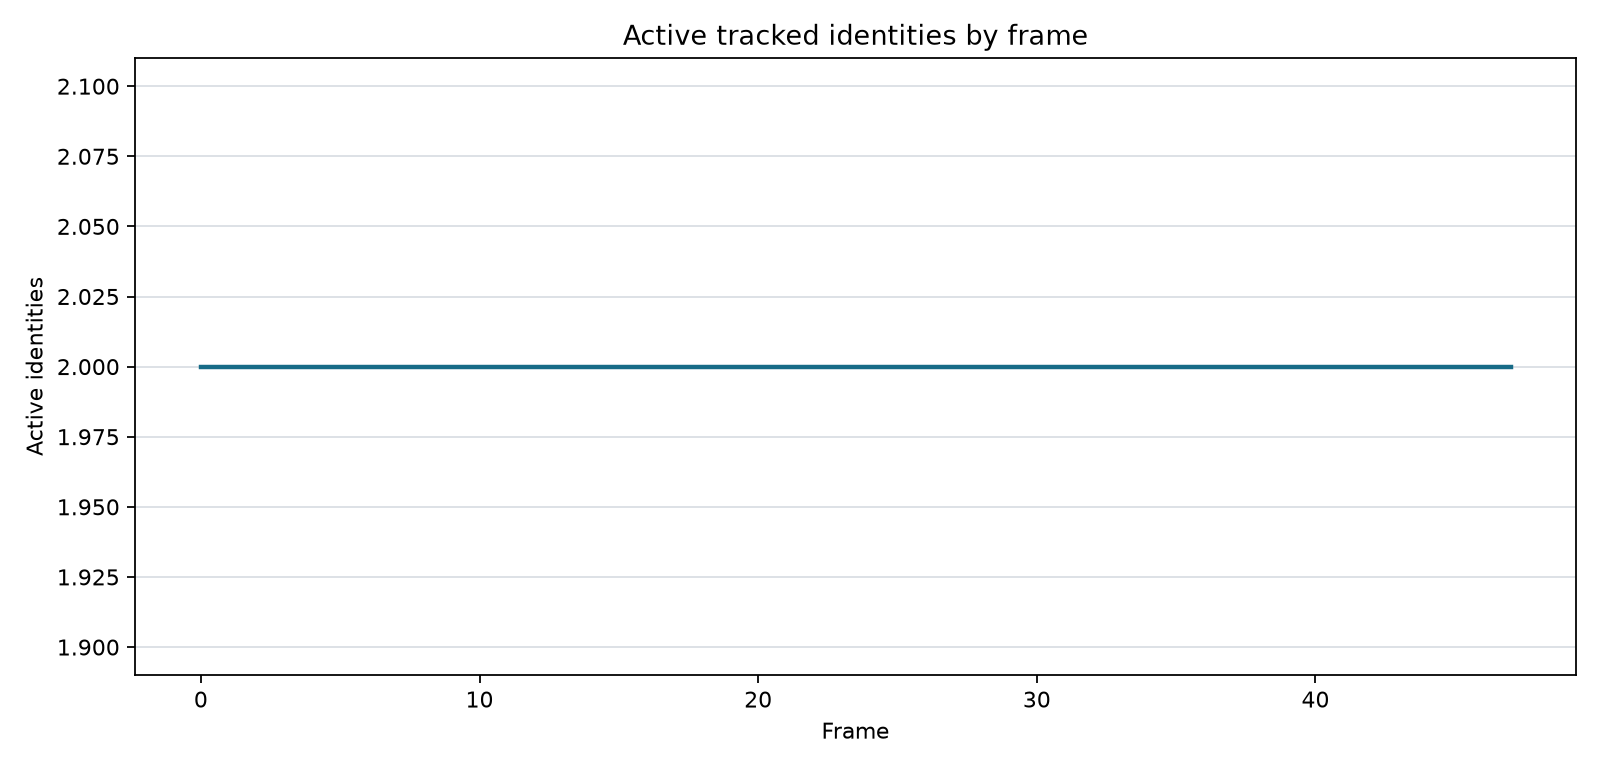

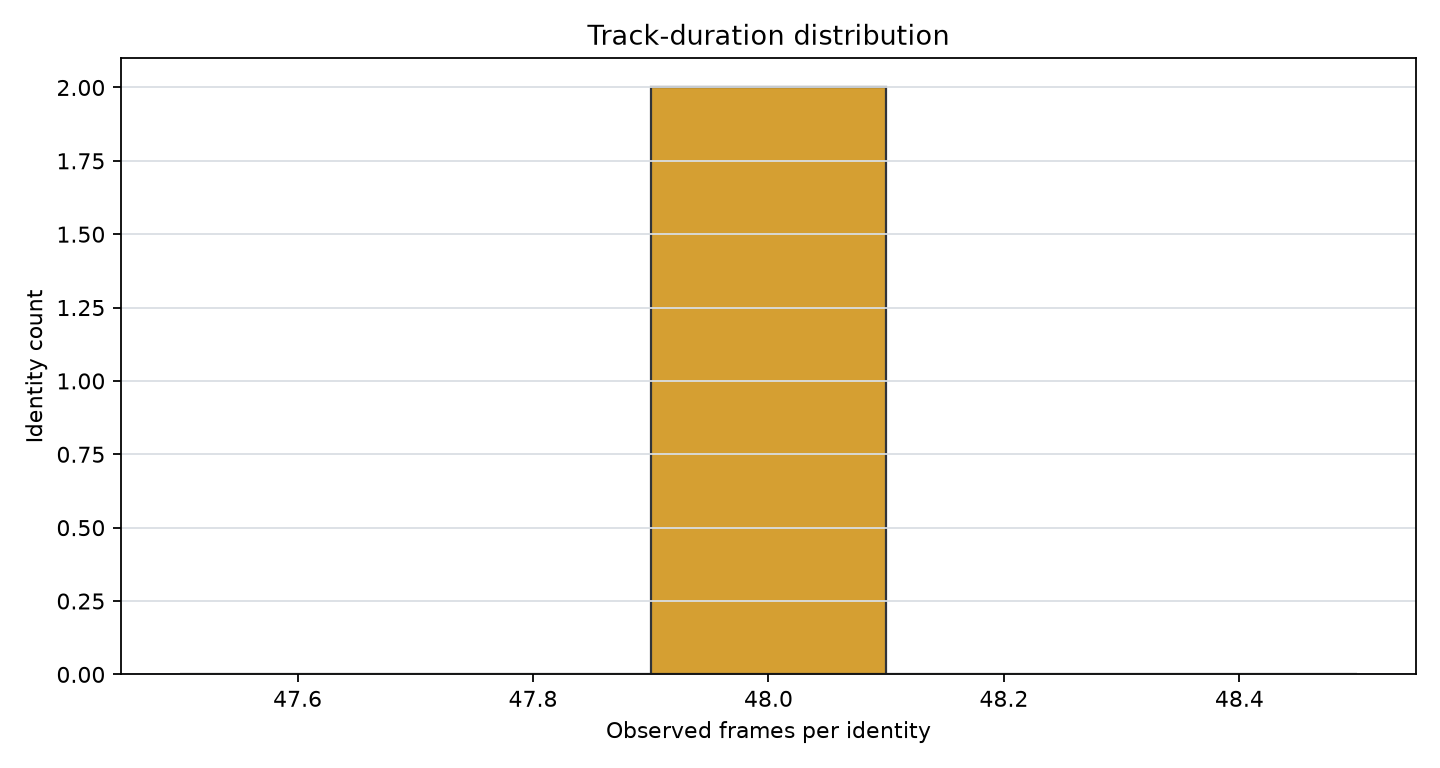

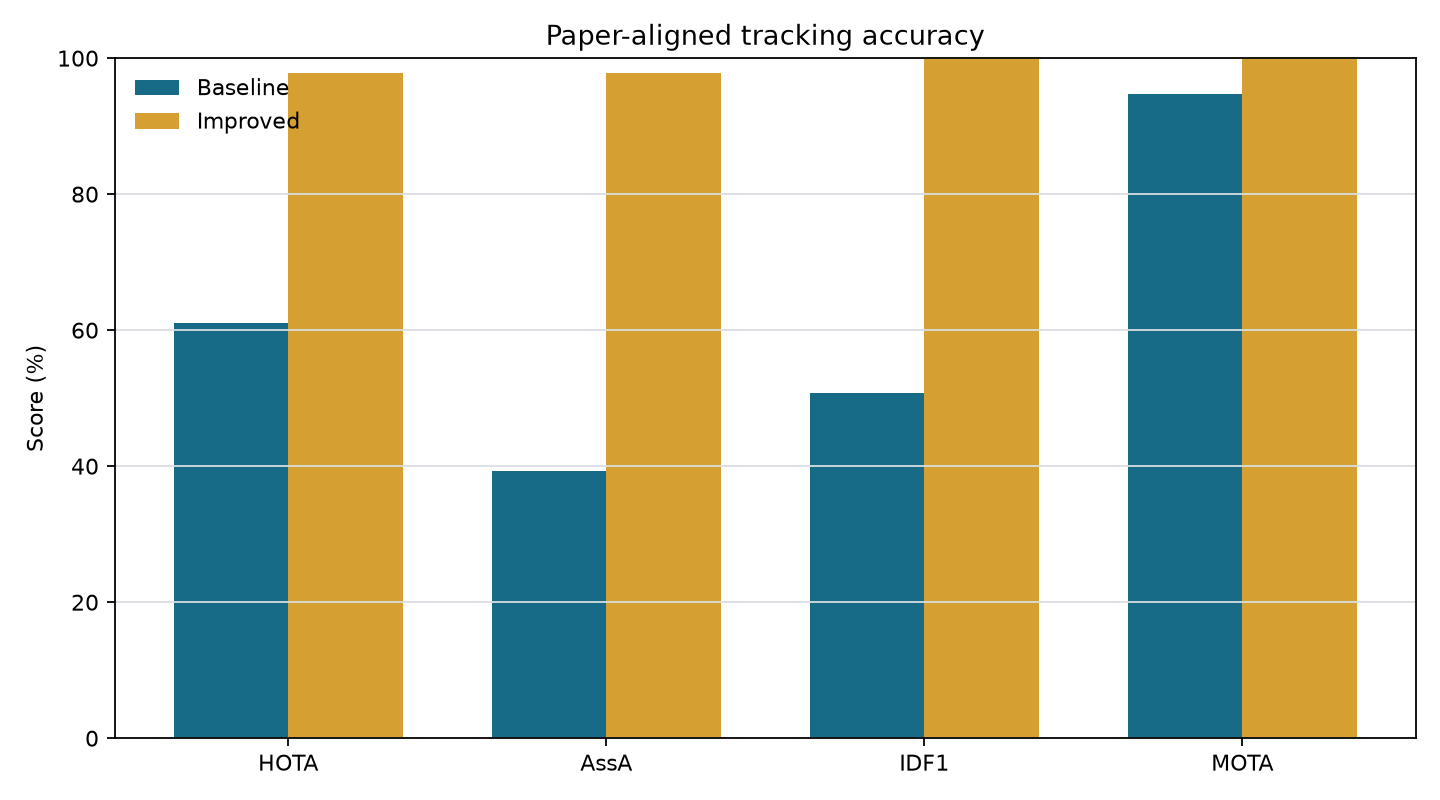

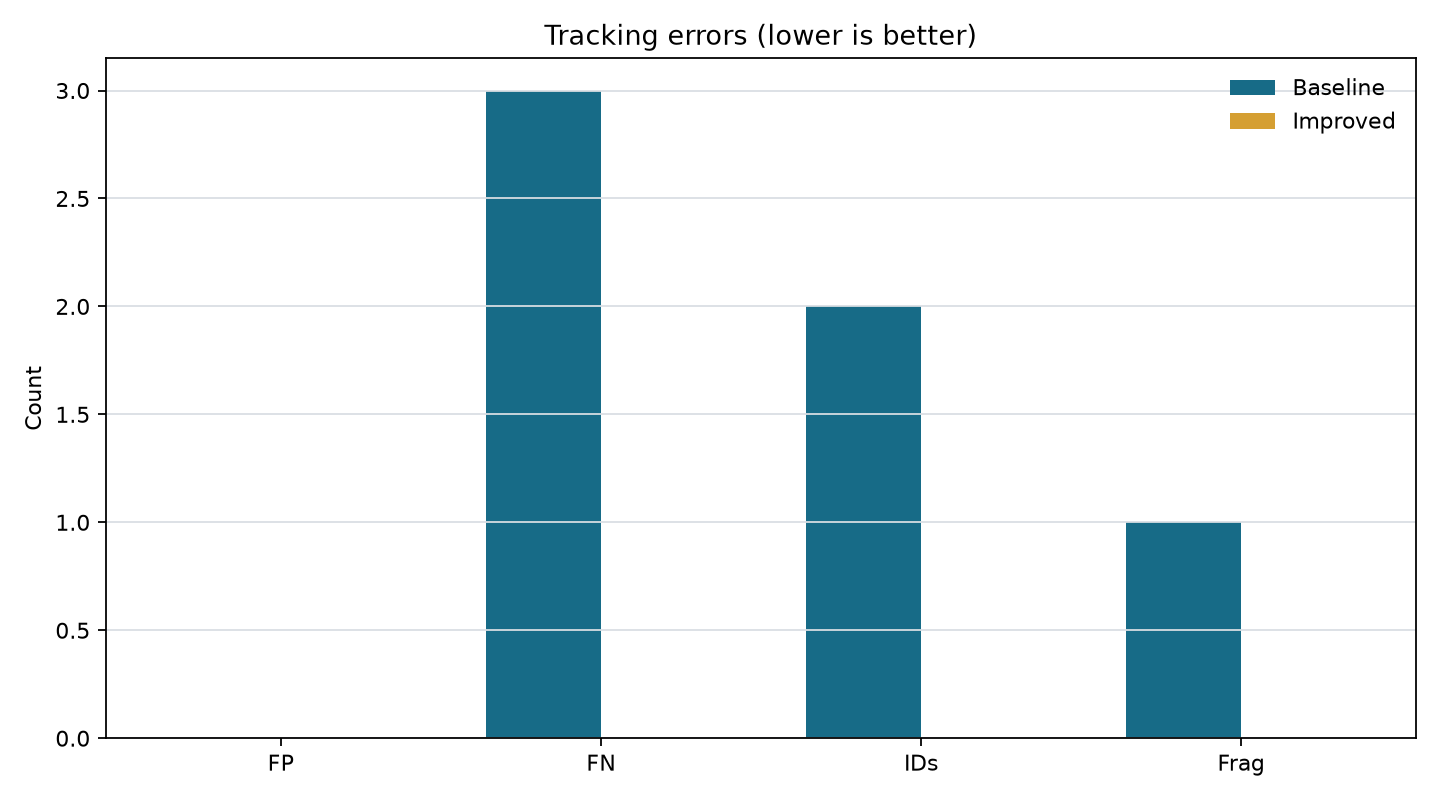

,event,frame,local_id,global_id,decision,similarity,score,backend
0,identity_assignment,0,2.0,1.0,new_identity,NaN,NaN,NaN
1,identity_assignment,0,1.0,2.0,new_identity,NaN,NaN,NaN
2,scene_cut,24,NaN,NaN,NaN,NaN,41.310276,pyscenedetect
3,identity_assignment,24,2.0,1.0,recovered,0.983442,NaN,NaN
4,identity_assignment,24,1.0,2.0,recovered,0.988604,NaN,NaN


In [6]:
for plot_name in [
    "active_identities_over_time.png",
    "track_duration_distribution.png",
    "paper_metrics_comparison.png",
    "tracking_errors_comparison.png",
]:
    plot_path = IMPROVED_OUTPUT / plot_name
    if plot_path.exists():
        display(Image(filename=str(plot_path)))

events_path = IMPROVED_OUTPUT / "events.jsonl"
events = [json.loads(line) for line in events_path.read_text(encoding="utf-8").splitlines() if line]
display(pd.DataFrame(events).head(20))
display(Video(str(IMPROVED_OUTPUT / "annotated_improved.mp4"), embed=True, width=720))

## Takeaways

Use the comparison table—not the visual impression alone—to decide whether cut-aware recovery helped. On football footage, identical kits can make person ReID ambiguous; the conservative threshold deliberately favors a new ID over a false merge. Report demo findings only as pipeline validation until football identity annotations are available.